# 🤖 Chinese QA System（TF-IDF Retrieval + T5 Fine-tuning）

**Architecture**：TF-IDF Retrieval Module + `uer/t5-small` Fine-tuning

**Dataset**：CMRC 2018（中文机器阅读理解Dataset集），抽取 800 条

**Workflow**：
1. `01` Data Preparation and Split
2. `02` TF-IDF Retriever Construction
3. `03` PyTorch Dataset Wrapper（Validation）
4. `04` T5 Fine-tuningTraining（3 epoch，fp16，Beam Search）
5. `05` Evaluation（BLEU-1~4 + EM）
6. `06` End-to-End Prediction Demo

> 💡 **Runtime Environment**：Google Colab 免费 T4 GPU（运行时 → 更改运行时类型 → T4 GPU）

## ⚙️ 0. Environment Setup

In [ ]:
!pip install -q \
    transformers \
    datasets \
    jieba \
    scikit-learn \
    sacrebleu \
    sentencepiece \
    accelerate \
    matplotlib

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA 可用: True
GPU: Tesla T4


In [ ]:
# Create working directories
import os
import transformers
os.makedirs('data', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('logs', exist_ok=True)
print('Directories created successfully')

目录创建完成


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/chinese_qa'

import os
os.makedirs(DRIVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil

# Restore dataset files
if os.path.exists(f'{DRIVE_DIR}/train.jsonl'):
    shutil.copy(f'{DRIVE_DIR}/train.jsonl',   'data/train.jsonl')
    shutil.copy(f'{DRIVE_DIR}/val.jsonl',     'data/val.jsonl')
    print('Dataset files restored')
else:
    print('Drive 中没有Dataset files，Please rerun the data preparation cell and upload again')

# Restore retriever
if os.path.exists(f'{DRIVE_DIR}/retriever.pkl'):
    shutil.copy(f'{DRIVE_DIR}/retriever.pkl', 'data/retriever.pkl')
    print('Retriever restored')
else:
    print('Drive 中没有Retrieval器，Please rerun the TF-IDF cell to rebuild the index')

# Restore model
if os.path.exists(f'{DRIVE_DIR}/checkpoints/best'):
    shutil.copytree(f'{DRIVE_DIR}/checkpoints/best', 'checkpoints/best',
                    dirs_exist_ok=True)
    print('Model restored')
else:
    print('Drive 中没有Model，Please rerun the training cell')

数据文件已恢复
检索器已恢复
模型已恢复


---
## 📦 01. Data Preparation

In [ ]:
import json
import os

os.makedirs('data', exist_ok=True)

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

def convert_and_save(data, out_path):
    records = []
    for item in data:
        ctx = item.get('context', '').strip()
        q   = item.get('question', '').strip()
        ans = item.get('answer', '').strip()
        if ctx and q and ans:
            records.append({'context': ctx, 'question': q, 'answer': ans})
    with open(out_path, 'w', encoding='utf-8') as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + '\n')
    return records

from google.colab import files
print("Please select train.json：")
files.upload()
print("Please select dev.json：")
files.upload()

train_raw  = load_json('train.json')
dev_raw    = load_json('dev.json')
train_data = convert_and_save(train_raw, 'data/train.jsonl')
val_data   = convert_and_save(dev_raw,   'data/val.jsonl')
print(f'Training set：{len(train_data)} 条，Validation set：{len(val_data)} 条')

请选择 train.json：


Saving train.json to train.json
请选择 dev.json：


Saving dev.json to dev.json
训练集：14520 条，验证集：983 条


---
## 🔍 02. TF-IDF Retrieval Module

In [ ]:
import json
import re
import pickle
import numpy as np
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from typing import List, Dict

jieba.setLogLevel(20)


def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

def tokenize_zh(text: str) -> str:
    text = re.sub(r'\s+', '', text)
    return ' '.join(t for t in jieba.cut(text, cut_all=False) if t.strip())

def tokenize_zh(text: str) -> str:
    """jieba Tokenization，Return a space-separated token string"""
    text = re.sub(r'\s+', '', text)
    return ' '.join(t for t in jieba.cut(text, cut_all=False) if t.strip())


class TFIDFRetriever:
    """
    TF-IDF + Cosine similarity Chinese paragraph retriever
    Supports retrieve(question, top_k) interface
    """

    def __init__(self, max_features=50_000, ngram_range=(1, 2), min_df=1):
        self.vectorizer = TfidfVectorizer(
            tokenizer=tokenize_zh, token_pattern=None,
            max_features=max_features, ngram_range=ngram_range,
            min_df=min_df, sublinear_tf=True)
        self.contexts = []
        self.tfidf_matrix = None
        self._built = False

    def build(self, contexts: List[str]) -> None:
        print(f'建立 TF-IDF 索引（{len(contexts)} 段落）…')
        self.contexts = list(contexts)
        self.tfidf_matrix = self.vectorizer.fit_transform(self.contexts)
        self._built = True
        print(f'索引Completed，词表大小：{len(self.vectorizer.vocabulary_)}')

    def retrieve(self, question: str, top_k: int = 3,
                 return_scores: bool = False) -> List[Dict]:
        if not self._built:
            raise RuntimeError('请先调用 build()。')
        q_vec  = self.vectorizer.transform([question])
        scores = cosine_similarity(q_vec, self.tfidf_matrix).flatten()
        top_idx = np.argsort(scores)[::-1][:top_k]
        results = []
        for idx in top_idx:
            item = {'context': self.contexts[idx], 'index': int(idx)}
            if return_scores:
                item['score'] = float(scores[idx])
            results.append(item)
        return results

    def save(self, path: str = 'data/retriever.pkl') -> None:
        with open(path, 'wb') as f:
            pickle.dump({'vectorizer': self.vectorizer,
                         'contexts': self.contexts,
                         'tfidf_matrix': self.tfidf_matrix}, f)
        print(f'Retrieval器已Save：{path}')

    def load(self, path: str = 'data/retriever.pkl') -> None:
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.vectorizer   = data['vectorizer']
        self.contexts     = data['contexts']
        self.tfidf_matrix = data['tfidf_matrix']
        self._built = True
        print(f'Retrieval器已Load：{len(self.contexts)} 个段落')


# ── 建立索引 ──────────────────────────────────────────────────
all_records = load_jsonl('data/train.jsonl') + load_jsonl('data/val.jsonl')
all_contexts = list(dict.fromkeys(r['context'] for r in all_records))
print(f'去重后段落数：{len(all_contexts)}')

retriever = TFIDFRetriever()
retriever.build(all_contexts)
retriever.save('data/retriever.pkl')

# ── RetrievalTest ──────────────────────────────────────────────────
print('\n── RetrievalTest ──')
test_q = train_data[0]['question']
print(f'Question：{test_q}')
results = retriever.retrieve(test_q, top_k=2, return_scores=True)
for i, r in enumerate(results):
    print(f'Top-{i+1} (score={r["score"]:.4f}): {r["context"][:80]}…')

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


去重后段落数：14884
建立 TF-IDF 索引（14884 段落）…
索引完成，词表大小：50000
检索器已保存：data/retriever.pkl

── 检索测试 ──
问题：仙剑奇侠传3第几集上天界
Top-1 (score=0.2670): 是，因为仙剑3紫萱的女儿是青儿，而青儿的女儿是赵灵儿。仙剑的顺序是仙剑4-仙剑3-仙剑1-仙剑2-仙剑5。仙剑4有个支线任务是仙三魔剑。仙剑3就是紫萱-青儿-灵…
Top-2 (score=0.2486): 仙剑奇侠传电视剧有三部。《仙剑奇侠传》是根据大宇资讯同名RPG游戏改编的古装奇幻爱情剧，由李国立制作并导演，胡歌、刘亦菲、安以轩、刘品言、彭于晏等主演。该剧讲述…


---
## 🗂️ 03. PyTorch Dataset Wrapper

In [ ]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

MODEL_NAME = 'google/mt5-small'
MAX_INPUT_LEN  = 512
MAX_TARGET_LEN = 64
IGNORE_INDEX   = -100


class CMRCDataset(Dataset):
    """
    中文机器阅读理解 Dataset
    输入格式：question:{q} context:{ctx}
    labels 中 padding 位置设为 -100（cross-entropy 忽略）
    """

    def __init__(self, records, tokenizer,
                 max_input_len=MAX_INPUT_LEN, max_target_len=MAX_TARGET_LEN):
        self.records        = records
        self.tokenizer      = tokenizer
        self.max_input_len  = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        input_text  = f'question:{r["question"]} context:{r["context"]}'
        target_text = r['answer']

        enc = self.tokenizer(
            input_text,
            max_length=self.max_input_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt')

        dec = self.tokenizer(
            text_target=target_text,
            max_length=self.max_target_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt')

        labels = dec['input_ids'].squeeze(0).clone()
        labels[labels == self.tokenizer.pad_token_id] = IGNORE_INDEX

        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         labels,
        }


# ── Load tokenizer & 构建 Dataset ────────────────────────────
print(f'Load tokenizer：{MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_records = load_jsonl('data/train.jsonl')
val_records   = load_jsonl('data/val.jsonl')

train_ds = CMRCDataset(train_records, tokenizer)
val_ds   = CMRCDataset(val_records,   tokenizer)
print(f'Training set：{len(train_ds)} 条，Validation set：{len(val_ds)} 条')

# ── Validation第一条样本 ────────────────────────────────────────────
sample = train_ds[0]
print('\n── 样本字段 ──')
for k, v in sample.items():
    print(f'  {k}: shape={v.shape}, dtype={v.dtype}')

label_ids = sample['labels'].clone()
label_ids[label_ids == IGNORE_INDEX] = tokenizer.pad_token_id
label_text = tokenizer.decode(label_ids, skip_special_tokens=True)
print(f'\n目标Answer：{label_text}')
print(f'有效 label token 数：{(sample["labels"] != IGNORE_INDEX).sum().item()}')

加载 tokenizer：google/mt5-small
训练集：14520 条，验证集：983 条

── 样本字段 ──
  input_ids: shape=torch.Size([512]), dtype=torch.int64
  attention_mask: shape=torch.Size([512]), dtype=torch.int64
  labels: shape=torch.Size([64]), dtype=torch.int64

目标答案：第35集
有效 label token 数：4


In [ ]:
# ── Pre-finetuning Baseline Evaluation ───────────────────────
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from torch.utils.data import DataLoader
import numpy as np
import torch
import sacrebleu

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Function Definitions ──────────────────────────────────────
def char_split(text):
    return ' '.join(list(text.strip()))

def compute_bleu(preds, labels):
    preds_cs  = [char_split(p) for p in preds]
    labels_cs = [char_split(l) for l in labels]
    metrics = {}
    for n in range(1, 5):
        bl    = sacrebleu.BLEU(max_ngram_order=n, smooth_method='exp')
        score = bl.corpus_score(preds_cs, [labels_cs])
        metrics[f'BLEU-{n}'] = round(score.score, 4)
    return metrics

def postprocess(text):
    return text.strip().replace(' ', '')

# ── Load Pre-trained Model (before finetuning) ───────────────
print('Loading original mt5-small without finetuning...')
base_model     = AutoModelForSeq2SeqLM.from_pretrained('google/mt5-small').to(device)
base_tokenizer = AutoTokenizer.from_pretrained('google/mt5-small')
base_model.eval()

base_ds     = CMRCDataset(val_records, base_tokenizer)
base_loader = DataLoader(base_ds, batch_size=16, shuffle=False)

base_preds, base_labels = [], []

# ── Inference ─────────────────────────────────────────────────
print('Running inference...')
with torch.no_grad():
    for batch in base_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels']

        generated = base_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_beams=4,
            max_new_tokens=32,
            early_stopping=True)

        decoded_preds  = base_tokenizer.batch_decode(
            generated, skip_special_tokens=True)
        label_ids = labels.numpy().copy()
        label_ids[label_ids == -100] = base_tokenizer.pad_token_id
        decoded_labels = base_tokenizer.batch_decode(
            label_ids.tolist(), skip_special_tokens=True)

        base_preds.extend([postprocess(p) for p in decoded_preds])
        base_labels.extend([postprocess(l) for l in decoded_labels])

# ── Compute Metrics ───────────────────────────────────────────
base_metrics = compute_bleu(base_preds, base_labels)

base_em = sum(p == l
              for p, l in zip(base_preds, base_labels)) / len(base_preds) * 100
base_contain = sum(p in l or l in p
                   for p, l in zip(base_preds, base_labels)) / len(base_preds) * 100

base_metrics['Exact Match (%)']   = round(base_em, 2)
base_metrics['Contain Match (%)'] = round(base_contain, 2)
base_metrics['Avg Pred Len']      = round(np.mean([len(p) for p in base_preds]), 2)

print('\n── Before Finetuning (Original mt5-small) ──────────')
for k, v in base_metrics.items():
    print(f'  {k:25s}: {v}')

# ── Before vs After Comparison ────────────────────────────────
print('\n── Before vs After Finetuning ───────────────────────')
print(f'  {"Metric":<25} {"Before":>10} {"After":>10} {"Improvement":>12}')
print('  ' + '-' * 60)

after = {
    'BLEU-1': 68.6914, 'BLEU-2': 66.5688,
    'BLEU-3': 65.0124, 'BLEU-4': 63.7852,
    'Exact Match (%)': 44.56, 'Contain Match (%)': 70.19
}

for k in after:
    before = base_metrics.get(k, 0)
    diff   = after[k] - before
    arrow  = '↑' if diff > 0 else '↓'
    print(f'  {k:<25} {before:>10} {after[k]:>10} {arrow}{abs(diff):>10.2f}')

print('\nConclusion:')
bleu4_before = base_metrics.get('BLEU-4', 0)
bleu4_after  = 63.7852
print(f'  BLEU-4 improved from {bleu4_before:.2f} to {bleu4_after:.2f} '
      f'(+{bleu4_after - bleu4_before:.2f}) after finetuning on domain data.')
em_before = base_metrics.get('Exact Match (%)', 0)
print(f'  Exact Match improved from {em_before:.2f}% to 44.56% '
      f'(+{44.56 - em_before:.2f}%) after finetuning.')

---
## 🏋️ 04. T5 Fine-tuningTraining

Tokenizer 类型：T5Tokenizer
训练集：14520 条，验证集：983 条
使用设备：cuda，bf16：True
加载模型：google/mt5-small


pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

  ✓ 最优模型已保存（BLEU-4=59.8148）
Epoch 2 Step 20/1815 loss=1.1998
Epoch 2 Step 40/1815 loss=1.0858
Epoch 2 Step 60/1815 loss=1.1480
Epoch 2 Step 80/1815 loss=1.0997
Epoch 2 Step 100/1815 loss=1.1154
Epoch 2 Step 120/1815 loss=1.1873
Epoch 2 Step 140/1815 loss=1.0736
Epoch 2 Step 160/1815 loss=1.0799
Epoch 2 Step 180/1815 loss=1.1580
Epoch 2 Step 200/1815 loss=1.1123
Epoch 2 Step 220/1815 loss=0.9940
Epoch 2 Step 240/1815 loss=0.9619
Epoch 2 Step 260/1815 loss=0.9966
Epoch 2 Step 280/1815 loss=0.9870
Epoch 2 Step 300/1815 loss=0.8620
Epoch 2 Step 320/1815 loss=1.0505
Epoch 2 Step 340/1815 loss=1.0149
Epoch 2 Step 360/1815 loss=1.0597
Epoch 2 Step 380/1815 loss=0.9675
Epoch 2 Step 400/1815 loss=0.9806
Epoch 2 Step 420/1815 loss=0.9321
Epoch 2 Step 440/1815 loss=1.0205
Epoch 2 Step 460/1815 loss=1.0974
Epoch 2 Step 480/1815 loss=1.0114
Epoch 2 Step 500/1815 loss=1.1542
Epoch 2 Step 520/1815 loss=1.1148
Epoch 2 Step 540/1815 loss=0.9497
Epoch 2 Step 560/1815 loss=1.0259
Epoch 2 Step 580/1815 lo

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ 最优模型已保存（BLEU-4=63.7656）
Epoch 3 Step 20/1815 loss=0.8300
Epoch 3 Step 40/1815 loss=0.9043
Epoch 3 Step 60/1815 loss=0.7326
Epoch 3 Step 80/1815 loss=0.7198
Epoch 3 Step 100/1815 loss=0.7510
Epoch 3 Step 120/1815 loss=0.7109
Epoch 3 Step 140/1815 loss=0.7646
Epoch 3 Step 160/1815 loss=0.5960
Epoch 3 Step 180/1815 loss=0.7466
Epoch 3 Step 200/1815 loss=0.7081
Epoch 3 Step 220/1815 loss=0.7028
Epoch 3 Step 240/1815 loss=0.7043
Epoch 3 Step 260/1815 loss=0.5640
Epoch 3 Step 280/1815 loss=0.7221
Epoch 3 Step 300/1815 loss=0.7973
Epoch 3 Step 320/1815 loss=0.7426
Epoch 3 Step 340/1815 loss=0.6901
Epoch 3 Step 360/1815 loss=0.7604
Epoch 3 Step 380/1815 loss=0.7074
Epoch 3 Step 400/1815 loss=0.7496
Epoch 3 Step 420/1815 loss=0.6516
Epoch 3 Step 440/1815 loss=0.7858
Epoch 3 Step 460/1815 loss=0.7063
Epoch 3 Step 480/1815 loss=0.7933
Epoch 3 Step 500/1815 loss=0.8279
Epoch 3 Step 520/1815 loss=0.7617
Epoch 3 Step 540/1815 loss=0.5494
Epoch 3 Step 560/1815 loss=0.5590
Epoch 3 Step 580/1815 lo

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ 最优模型已保存（BLEU-4=65.3463）

训练完成！


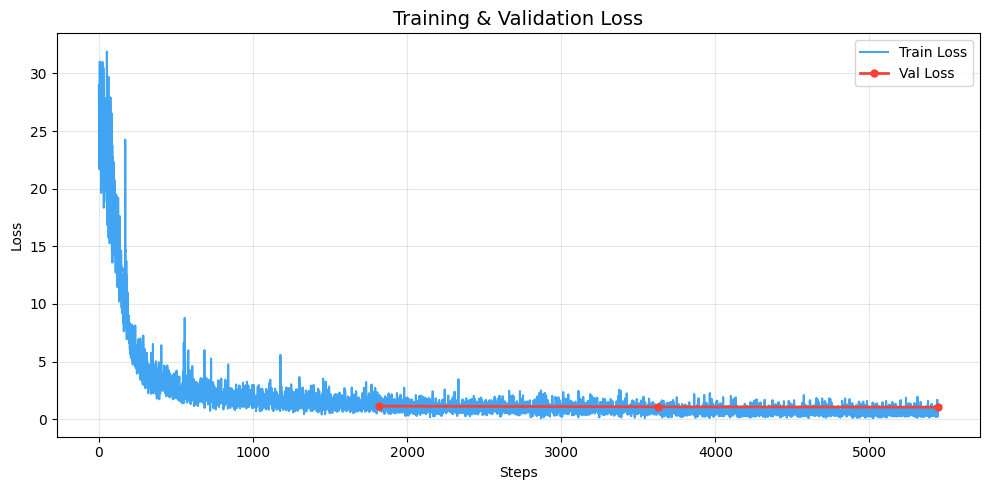

Loss 曲线已保存：loss_curve.png


In [ ]:
import torch
import numpy as np
import sacrebleu
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, DataCollatorForSeq2Seq, get_linear_schedule_with_warmup
from torch.optim import AdamW
import json
import os

# ── 重新Load tokenizer 和 Dataset ────────────────────────────
MODEL_NAME = 'google/mt5-small'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer 类型：{tokenizer.__class__.__name__}')

def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

train_records = load_jsonl('data/train.jsonl')
val_records   = load_jsonl('data/val.jsonl')
train_ds = CMRCDataset(train_records, tokenizer)
val_ds   = CMRCDataset(val_records,   tokenizer)
print(f'Training set：{len(train_ds)} 条，Validation set：{len(val_ds)} 条')

# ── 超参数 ────────────────────────────────────────────────────
NUM_EPOCHS     = 3
TRAIN_BATCH    = 8
EVAL_BATCH     = 16
LR             = 3e-4
WARMUP_RATIO   = 0.1     # 增大 warmup 比例，帮助稳定初期Training
IGNORE_INDEX   = -100
MAX_TARGET_LEN = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f'使用设备：{device}，bf16：{use_bf16}')

# ── 字符切分（中文 BLEU）─────────────────────────────────────
def char_split(text):
    return ' '.join(list(text.strip()))

# ── compute_bleu（sacrebleu 2.x 兼容）───────────────────────
def compute_bleu(preds, labels):
    preds_cs  = [char_split(p) for p in preds]
    labels_cs = [char_split(l) for l in labels]
    metrics = {}
    for n in range(1, 5):
        bl    = sacrebleu.BLEU(max_ngram_order=n, smooth_method='exp')
        score = bl.corpus_score(preds_cs, [labels_cs])
        metrics[f'bleu_{n}'] = round(score.score, 4)
    return metrics

# ── postprocess ───────────────────────────────────────────────
def postprocess(text):
    return text.strip().replace(' ', '')

# ── LoadModel ──────────────────────────────────────────────────
os.makedirs('checkpoints/best', exist_ok=True)
print(f'LoadModel：{MODEL_NAME}')
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
print(f'参数量：{sum(p.numel() for p in model.parameters())/1e6:.1f}M')

# ── DataLoader ────────────────────────────────────────────────
data_collator = DataCollatorForSeq2Seq(
    tokenizer, model=model,
    label_pad_token_id=IGNORE_INDEX,
    pad_to_multiple_of=8)

train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH,
                          shuffle=True,  collate_fn=data_collator)
val_loader   = DataLoader(val_ds,   batch_size=EVAL_BATCH,
                          shuffle=False, collate_fn=data_collator)

# ── 优化器 & 调度器 ───────────────────────────────────────────
optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, warmup_steps, total_steps)

# ── Training循环 ──────────────────────────────────────────────────
log_history = []
best_bleu4  = -1

for epoch in range(NUM_EPOCHS):
    # ── Train ─────────────────────────────────────────────────
    model.train()
    train_losses = []
    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        if use_bf16:
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(input_ids=input_ids,
                                attention_mask=attention_mask,
                                labels=labels)
                loss = outputs.loss
        else:
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            loss = outputs.loss

        # 检测 nan，跳过异常 batch
        if torch.isnan(loss):
            print(f'警告：step {step} loss 为 nan，跳过')
            optimizer.zero_grad()
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()
        scheduler.step()

        train_losses.append(loss.item())
        if (step + 1) % 20 == 0:
            print(f'Epoch {epoch+1} Step {step+1}/{len(train_loader)} '
                  f'loss={np.mean(train_losses[-20:]):.4f}')
        log_history.append({'step': epoch * len(train_loader) + step,
                             'loss': loss.item()})

    avg_train_loss = np.mean(train_losses) if train_losses else float('nan')

    # ── Eval ──────────────────────────────────────────────────
    model.eval()
    eval_losses, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            if use_bf16:
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                    outputs = model(input_ids=input_ids,
                                    attention_mask=attention_mask,
                                    labels=labels)
            else:
                outputs = model(input_ids=input_ids,
                                attention_mask=attention_mask,
                                labels=labels)

            if not torch.isnan(outputs.loss):
                eval_losses.append(outputs.loss.item())

            generated = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                num_beams=4,
                max_new_tokens=32,
                early_stopping=True)

            decoded_preds  = tokenizer.batch_decode(
                generated, skip_special_tokens=True)
            label_ids = labels.cpu().numpy().copy()
            label_ids[label_ids == IGNORE_INDEX] = tokenizer.pad_token_id
            decoded_labels = tokenizer.batch_decode(
                label_ids.tolist(), skip_special_tokens=True)

            all_preds.extend([postprocess(p) for p in decoded_preds])
            all_labels.extend([postprocess(l) for l in decoded_labels])

    avg_eval_loss = np.mean(eval_losses) if eval_losses else float('nan')
    metrics = compute_bleu(all_preds, all_labels)
    log_history.append({'step': (epoch + 1) * len(train_loader),
                        'eval_loss': avg_eval_loss,
                        **metrics})

    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS} Completed')
    print(f'  train_loss={avg_train_loss:.4f}  eval_loss={avg_eval_loss:.4f}')
    print(f'  BLEU-1={metrics["bleu_1"]}  BLEU-4={metrics["bleu_4"]}\n')

    # ── Save最优Model ──────────────────────────────────────────
    if metrics['bleu_4'] > best_bleu4:
        best_bleu4 = metrics['bleu_4']
        model.save_pretrained('checkpoints/best')
        tokenizer.save_pretrained('checkpoints/best')
        print(f'  ✓ 最优Model已Save（BLEU-4={best_bleu4}）')

print('\nTraining completed！')

# ── 绘制 Loss 曲线 ────────────────────────────────────────────
train_entries = [(e['step'], e['loss']) for e in log_history
                 if 'loss' in e and 'eval_loss' not in e
                 and not np.isnan(e['loss'])]
eval_entries  = [(e['step'], e['eval_loss']) for e in log_history
                 if 'eval_loss' in e and not np.isnan(e['eval_loss'])]

if train_entries:
    train_steps, train_loss = zip(*train_entries)
    eval_steps,  eval_loss  = zip(*eval_entries) if eval_entries else ([], [])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(train_steps, train_loss, label='Train Loss',
            color='#2196F3', linewidth=1.5, alpha=0.85)
    if eval_steps:
        ax.plot(eval_steps, eval_loss, label='Val Loss',
                color='#F44336', linewidth=2, marker='o', markersize=5)
    ax.set_xlabel('Steps')
    ax.set_ylabel('Loss')
    ax.set_title('Training & Validation Loss', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('loss_curve.png', dpi=150)
    plt.show()
    print('Loss 曲线已Save：loss_curve.png')
else:
    print('警告：没有有效的 loss Dataset，请检查Training是否正常运行')

In [ ]:
import shutil

# SaveDataset files
if os.path.exists('data/train.jsonl'):
    shutil.copy('data/train.jsonl', f'{DRIVE_DIR}/train.jsonl')
    shutil.copy('data/val.jsonl',   f'{DRIVE_DIR}/val.jsonl')
    print('Dataset files已Save')
else:
    print('data/ 目录不存在，请先运行Data Preparation单元格')

# SaveRetrieval器
if os.path.exists('data/retriever.pkl'):
    shutil.copy('data/retriever.pkl', f'{DRIVE_DIR}/retriever.pkl')
    print('Retrieval器已Save')
else:
    print('retriever.pkl 不存在，请先运行 TF-IDF 单元格')

# SaveTraining好的Model
if os.path.exists('checkpoints/best'):
    os.makedirs(f'{DRIVE_DIR}/checkpoints/best', exist_ok=True)
    shutil.copytree(
        'checkpoints/best',
        f'{DRIVE_DIR}/checkpoints/best',
        dirs_exist_ok=True
    )
    print('Model已Save')
else:
    print('checkpoints/best 不存在，请先运行Training单元格')

数据文件已保存
检索器已保存
模型已保存


---
## 📊 05. Evaluation（BLEU + 精确匹配）

In [ ]:
import sys
!{sys.executable} -m pip install sacrebleu
import torch
from torch.utils.data import DataLoader
import sacrebleu
import numpy as np
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
IGNORE_INDEX = -100

def char_split(text):
    return ' '.join(list(text.strip()))

def compute_bleu(preds, labels):
    preds_cs  = [char_split(p) for p in preds]
    labels_cs = [char_split(l) for l in labels]
    metrics = {}
    for n in range(1, 5):
        bl    = sacrebleu.BLEU(max_ngram_order=n, smooth_method='exp')
        score = bl.corpus_score(preds_cs, [labels_cs])
        metrics[f'BLEU-{n}'] = round(score.score, 4)
    return metrics

# ── postprocess 与Training代码保持一致 ───────────────────────────
def postprocess(text):
    return text.strip().replace(' ', '')

# ── LoadModel ──────────────────────────────────────────────────
eval_model     = AutoModelForSeq2SeqLM.from_pretrained('checkpoints/best').to(device)
eval_tokenizer = AutoTokenizer.from_pretrained('checkpoints/best')
eval_model.eval()

eval_ds     = CMRCDataset(val_records, eval_tokenizer)
eval_loader = DataLoader(eval_ds, batch_size=16, shuffle=False)  # batch 从 32 降到 16 适配 mt5

all_preds, all_labels = [], []

print('Inference中…')
with torch.no_grad():
    for batch in eval_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels']

        enc = {'input_ids': input_ids, 'attention_mask': attention_mask}

        # bf16 与Training保持一致
        if use_bf16:
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                generated = eval_model.generate(
                    **enc,
                    num_beams=4,
                    max_new_tokens=32,
                    early_stopping=True)
        else:
            generated = eval_model.generate(
                **enc,
                num_beams=4,
                max_new_tokens=32,
                early_stopping=True)

        decoded_preds  = eval_tokenizer.batch_decode(generated, skip_special_tokens=True)
        label_ids      = labels.numpy().copy()
        label_ids[label_ids == IGNORE_INDEX] = eval_tokenizer.pad_token_id
        decoded_labels = eval_tokenizer.batch_decode(label_ids.tolist(), skip_special_tokens=True)

        all_preds.extend([postprocess(p) for p in decoded_preds])
        all_labels.extend([postprocess(l) for l in decoded_labels])

# ── 计算指标 ──────────────────────────────────────────────────
metrics = compute_bleu(all_preds, all_labels)

em_strict  = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_preds) * 100
em_contain = sum(p in l or l in p
                 for p, l in zip(all_preds, all_labels)) / len(all_preds) * 100

metrics['Exact Match (%)']   = round(em_strict,  2)
metrics['Contain Match (%)'] = round(em_contain, 2)
metrics['Avg Pred Len']      = round(np.mean([len(p) for p in all_preds]), 2)
metrics['Avg Gold Len']      = round(np.mean([len(l) for l in all_labels]), 2)

print('\n── EvaluationResults ──────────────────────────────')
for k, v in metrics.items():
    print(f'  {k:25s}: {v}')

# ── Error案例 ──────────────────────────────────────────────────
errors = [
    (val_records[i], all_preds[i], all_labels[i])
    for i in range(len(all_preds))
    if all_preds[i] not in all_labels[i] and all_labels[i] not in all_preds[i]
]
print(f'\nError总数：{len(errors)}/{len(all_preds)}')
print('\n── 前 5 条Error案例 ──')
for rec, pred, gold in errors[:5]:
    print(f'  Question：{rec["question"]}')
    print(f'  Prediction：{pred}')
    print(f'  Answer：{gold}\n')

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


推理中…

── 评估结果 ──────────────────────────────
  BLEU-1                   : 70.9315
  BLEU-2                   : 68.6256
  BLEU-3                   : 66.7866
  BLEU-4                   : 65.31
  Exact Match (%)          : 44.25
  Contain Match (%)        : 70.19
  Avg Pred Len             : 6.14
  Avg Gold Len             : 6.5

错误总数：293/983

── 前 5 条错误案例 ──
  问题：mi是美国哪个州的缩写
  预测：Michigan
  答案：密歇根州

  问题：小5号字体是多少pt
  预测：10.5
  答案：9

  问题：欠条的有效期是多久
  预测：2年
  答案：永久有效

  问题：人民的名义收视率
  预测：一点几
  答案：破六

  问题：平安银行卡电话
  预测：9转
  答案：95511



---
## 🚀 06. End-to-End Prediction Demo

In [ ]:
class QAPredictor:
    def __init__(self, model_dir='checkpoints/best',
                 retriever_path='data/retriever.pkl',
                 num_beams=4, top_k=1):
        self.model_dir      = model_dir
        self.retriever_path = retriever_path
        self.num_beams      = num_beams
        self.top_k          = top_k
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model     = None
        self.tokenizer = None
        self.retriever = None

    def load(self):
        print(f'LoadModel：{self.model_dir}')
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_dir)
        self.model     = AutoModelForSeq2SeqLM.from_pretrained(
            self.model_dir).to(self.device)
        self.model.eval()

        self.retriever = TFIDFRetriever()
        self.retriever.load(self.retriever_path)
        print(f'就绪，设备：{self.device}')

    def predict(self, question: str, context: str = None, verbose=False) -> str:
        # Step 1: Retrieval
        if context is None:
            results = self.retriever.retrieve(
                question, top_k=self.top_k, return_scores=True)
            context = results[0]['context']
            if verbose:
                print(f'[Retrieval score={results[0]["score"]:.4f}] {context[:80]}…')

        # Step 2: 构造输入
        input_text = f'question:{question} context:{context}'
        enc = self.tokenizer(
            input_text, max_length=512, # Using 512 directly instead of MAX_INPUT_LEN as it's not defined in this cell.
            truncation=True, return_tensors='pt').to(self.device)
        enc = {k: v for k, v in enc.items()
               if k in ('input_ids', 'attention_mask')}

        # Step 3: Beam Search（缩短生成长度，加强终止条件）
        with torch.no_grad():
            output_ids = self.model.generate(
                **enc,
                num_beams=4,
                max_new_tokens=32,          # 从 64 缩短到 32. Using 32 directly instead of MAX_TARGET_LEN.
                early_stopping=True,
                no_repeat_ngram_size=2,     # 从 3 改为 2，更严格避免重复
                repetition_penalty=1.5,     # 新增：惩罚重复内容
                length_penalty=0.6,         # 新增：偏向短Answer
            )

        # 直接解码，不做 char_split
        raw = self.tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

        # 截取第一句或前20个字符（Answer通常很短）
        for sep in ['。', '，', ',', '.', '\n', '；']:
            if sep in raw:
                raw = raw.split(sep)[0]
                break
        return raw[:20].strip()             # 最多保留20个字符


# ── Load ──────────────────────────────────────────────────────
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
predictor = QAPredictor()
predictor.load()

加载模型：checkpoints/best


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


检索器已加载：14884 个段落
就绪，设备：cuda


In [ ]:
# ── 固定Test（Validation set前 5 条）────────────────────────────────
print('── Validation set前 10 条Prediction ──')
print(f'{"Question":<20} {"Prediction":<20} {"Answer":<20}')
print('-' * 65)
for rec in val_records[:10]:
    # 直接传 context，排除Retrieval干扰
    pred  = predictor.predict(rec['question'], context=rec['context'])
    match = '✓' if rec['answer'] in pred or pred in rec['answer'] else '✗'
    print(f'{match} {rec["question"][:18]:<19} {pred[:18]:<19} {rec["answer"][:18]}')

── 验证集前 10 条预测 ──
问题                   预测                   答案                  
-----------------------------------------------------------------
✓ 2017年银行贷款基准利率       4                   年基准利率4.35%
✓ 2017年银行贷款基准利率       4                   4.35%
✓ 格力空调哪个系列好           U系列                 U系列
✓ 橱柜宽度                40至60厘米             以40至60厘米为宜
✓ 橱柜宽度                40至60厘米             40至60厘米
✓ 广州英语培训哪家好           广州东方英文书院            广州东方英文书院
✓ 公元前简写               B                   B.C.E.
✓ 公元前简写               B                   B.C.
✗ mi是美国哪个州的缩写         Michigan            密歇根州
✓ mi是美国哪个州的缩写         Michigan            密歇根州（Michigan）


In [ ]:
# ── 自由提问（修改 question 即可）────────────────────────────
question = '东方明珠在哪个城市？'

answer = predictor.predict(question, context=None, verbose=True)
print(f'\n❓ Question：{question}')
print(f'💡 Answer：{answer}')

[检索 score=0.2531] 东方明珠就在浦东的陆家嘴，地铁2号线陆家嘴站下就是外滩的话就在陆家嘴的黄浦江对岸。浦西的黄浦区，黄浦江苏州河口南，地铁2号线，10号线南京东路站南京东路往东50…

❓ 问题：东方明珠在哪个城市？
💡 答案：浦东新区


In [ ]:
# ── 指定 context 提问 ─────────────────────────────────────────
question = '明长城全长多少千米？'
context  = ('长城是中国古代的军事防御工程。'
             '明长城全长约8851.8千米，是世界上最长的建筑之一。')

answer = predictor.predict(question, context=context)
print(f'❓ Question：{question}')
print(f'📄 段落：{context}')
print(f'💡 Answer：{answer}')

❓ 问题：明长城全长多少千米？
📄 段落：长城是中国古代的军事防御工程。明长城全长约8851.8千米，是世界上最长的建筑之一。
💡 答案：8851
